# Does the "rounding top" really warn of a decline? 🌄
### The dome distribution — a beautiful chart shape that, on the tape, predicts nothing special

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Distribution_signal%3F: Not_supported](https://img.shields.io/badge/Distribution_signal%3F-Not_supported-8b949e?style=flat-square)

Open any technical-analysis book and you'll meet the **rounding top** (a.k.a. the *dome distribution*): a long, smooth, arched roll-over where — the story goes — *smart money* is quietly **distributing** (selling into strength) while everyone else keeps buying. When price finally curves over and **breaks down** below the rim, that's your sell signal: the top is in, the decline begins.

It's a lovely picture — the exact bearish mirror of the rounding bottom / saucer base we already tested in [Study 416](../../416-rounding-bottom/). So we built the same kind of **mechanical detector**, flipped to look for domes instead of bowls — fit a parabola, demand a real inverted-U, a peak in the middle, and a confirmed support breakdown — and asked the only question that matters: *after a confirmed dome breakdown, shorted, does the stock do anything a random short wouldn't?* The honest answer is **no**.

> 📓 **Plain-language layer.** Want the *t*-stats, the base-rate comparison, the borrow cost and the placebo test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Two honest caveats up front.** (1) Chart figures are **partly subjective** — we test the closest *mechanical* definition and say so; a human chartist might draw the dome differently. (2) We use a fixed **30-name** basket (SPY + large-caps still trading today), which carries **survivorship** — but here it works *against* the bearish claim (the worst confirmed outcomes, delistings and bankruptcies, can't appear in a 2026-survivors panel). House style: [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rounding_top import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real() if HAVE_REAL else None
print("real rounding-top cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2004-01-02', 'end': '2026-06-30', 'years': 22.5, 'n_names': 30, 'fp': '9da1b7ce7758', 'base_len': 90, 'cost_bps': 5.0, 'borrow_bps': 30.0, 'h10': (10, 227, -0.76, -0.88, -0.59, 46, 43, -1.83, -1.89, -0.42, 0.684), 'h20': (20, 227, -1.61, -1.74, -1.14, 44, 42, -3.3, -3.34, -0.96, 0.827), 'h60': (60, 225, -4.39, -4.56, -3.32, 33, 37, -5.69, -5.41, -1.38, 0.891), 'rob_bl': [(60, 222, -0.78, -1.64, 0.75, 0.197), (90, 227, -1.61, -3.3, -0.96, 0.827), (120, 183, -1.73, -3.02, -1.03, 0.884)], 'rob_r2': [(0.45, 295, -1.4, -3.18, -0.59, 0.748), (0.55, 227, -1.61, -3.3, -0.96, 0.827), (0.7, 83, -1.9, -2.32, -0.93, 0.832)], 'syn': [(0.0, 145, -0.2, -0.4, -0.44, 0.42, 0.351, 53), (-0.1, 143, 3.18, 0.15, 5.37, 5.11, 0.0, 71)], 'syn_null_mean': -0.17, 'syn_null_sd': 0.95, 'syn_null_fire': 1, 'syn_null_seeds': 20}


real rounding-top cache present: True | names: 30


## The answer first

| Question | Answer |
|---|---|
| After a confirmed dome breakdown, shorted, do you make money? | **Sort of — but so does shorting almost anything the market later dislikes.** The short averages **-1.6% over 20 days** and **-4.4% over 60**. Sounds like a real edge…
| …is that **better** than shorting a random day in the same stock? | **No.** A *random* short in the same stocks earns **-1.1% / -3.3%** over the same windows — basically the same (both negative, because stocks drift up and shorting anything costs you that drift). The dome adds **nothing** over a random bet against the tape. |
| Could the shape just be **luck**? | **Looks like it.** Shuffle in random entry dates thousands of times and they beat the dome breakdown **~83–89%** of the time — nowhere near significant. |
| Is it 'distribution'? | **Not supported.** The breakdown return is indistinguishable from the ordinary cost of shorting an up-drifting market. No special smart-money footprint shows up. |

> The shape is real and pretty. The **edge** is a mirage: shorting the dome breakdown loses about what shorting anything else in the same stocks loses — to the market's own upward drift.

## 1 · The claim

> *"A rounding top is a dome-shaped distribution that forms over weeks or months. During the dome, **strong hands quietly sell into strength** while buyers pile in near the top. The smooth roll-over and the **breakdown below the rim** confirm the distribution phase is over — short the breakdown and ride the new downtrend."*

This is canon — the exact mirror of Edwards & Magee's rounding bottom, in every charting course. The believer's strongest version isn't "the shape is pretty" — it's that the breakdown marks a **regime change** from distribution to markdown, so the forward **short** return after a confirmed breakdown should **beat the cost of shorting the stock on an ordinary day**. That's the testable promise.

## 2 · So what?

If true, this would be gold for bears: a *visual* signal, drawable by eye, that flags the start of a decline. You'd scan charts for domes, short the breakdowns, and profit from the reversal.

But there's a trap here that's the **mirror image** of the one that sank the rounding bottom. Stocks **drift up** on average — which means shorting *anything*, on an *ordinary day*, already costs you money before the pattern gets a say. So a positive-looking short return after a dome breakdown proves nothing by itself: the only honest test is whether it beats shorting a **random day** in the same names. If it doesn't, the dome is just an elaborate way of picking a bad-but-not-special day to fight the tape.

## 3 · How would we even know?

We take SPY plus **29 large-caps** (22 years of daily bars) and run a **mechanical** rounding-top detector at every bar:

1. **A real dome.** Fit a parabola to the last ~90 days of closes; demand it actually curves *down* (negative curvature) and fits well.
2. **A peak in the middle.** The high point must sit *inside* the window, not at an edge — a dome, not a climb.
3. **A confirmed breakdown.** The close must cross back **below the rim** (the left-edge support) for the first time — the dome is finished.

Then we **short at the next day's open** (no cheating) and measure the forward 10 / 20 / 60-day return — against the **base rate** (shorting a random day in the same stock) and a **date-shuffle placebo**, with realistic costs *and* a stock-borrow rate on the short. **Mirage verdict if** the breakdown doesn't beat random shorts.

## 4 · The teardown — let's actually look

**First, what does the detector even find?** Here's one real dome it flagged — the fitted inverted-U and the breakdown bar. The shape detection works; that was never the question.

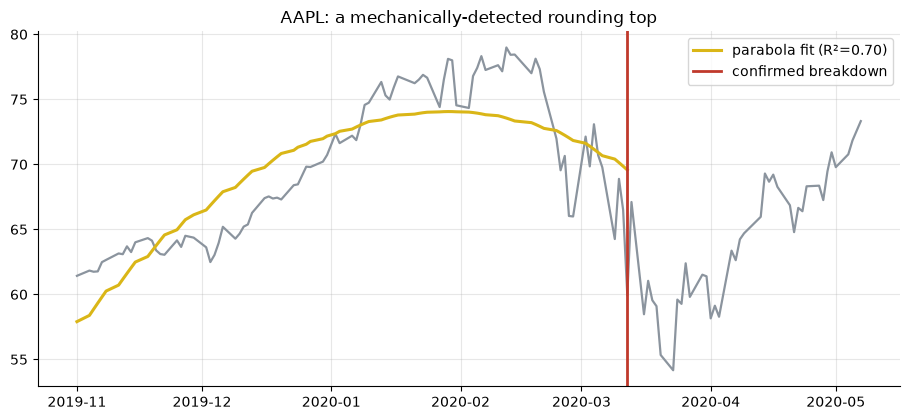

AAPL dome breakdown on 2020-03-12: fit R²=0.70


In [2]:
if HAVE_REAL:
    tk = 'AAPL'
    bars = PANEL[tk]
    bk = st.detect_breakdowns(bars, base_len=R['base_len'])
    if len(bk):
        bo = bk.index[len(bk)//2]
        i = bars.index.get_loc(bo)
        w = bars['close'].iloc[i-R['base_len']+1:i+40]
        fig, ax = plt.subplots(figsize=(9.2,4.3))
        ax.plot(w.index, w.values, color=GREY, lw=1.6)
        seg = np.log(bars['close'].iloc[i-R['base_len']+1:i+1].values)
        a,b,d,r2 = st._parabola_fit(seg)
        u = np.arange(len(seg)); fit = np.exp(a*u*u+b*u+d)
        ax.plot(w.index[:len(seg)], fit, color=AMBER, lw=2.2, label=f'parabola fit (R\u00b2={r2:.2f})')
        ax.axvline(bo, color=RED, lw=2, label='confirmed breakdown')
        ax.set_title(f'{tk}: a mechanically-detected rounding top'); ax.legend()
        plt.tight_layout(); plt.show()
        print(f'{tk} dome breakdown on {bo.date()}: fit R\u00b2={r2:.2f}')
else:
    print('(cache absent — detector demo skipped; numbers are frozen in R)')

The detector cleanly finds the figure: a smooth dome, a fitted parabola, a breakdown. The shape is genuinely *there*. Now the real question — **does shorting it pay?**

**The decisive chart.** Confirmed-breakdown short return (red) vs the **base rate** — shorting a random day in the same stocks (grey) — at three horizons. If the pattern means anything, red should be far more negative (more profitable for the short) than grey.

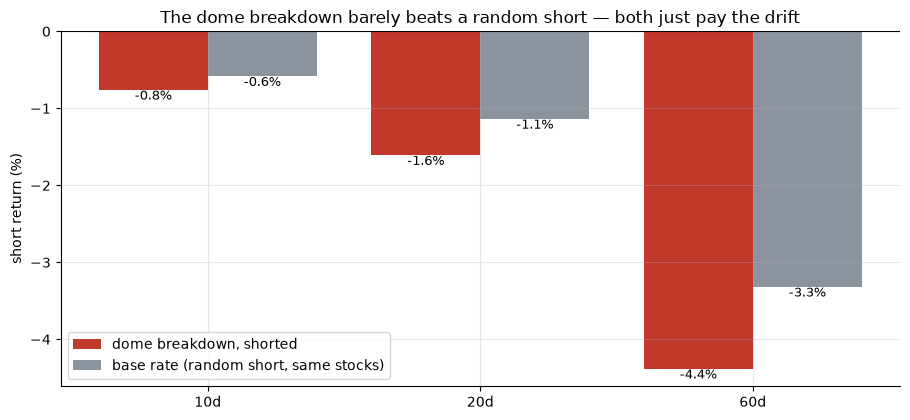

signal: [-0.76, -1.61, -4.39]  base: [-0.59, -1.14, -3.32]


In [3]:
hs = [10, 20, 60]
if HAVE_REAL:
    sig, base = [], []
    for h in hs:
        r = st.run_experiment(PANEL, base_len=R['base_len'], horizon=h, cost_bps=5.0, borrow_bps=30.0, placebo=False)
        sig.append(r['gross_mean']*100); base.append(r['base_mean']*100)
else:
    sig = [R['h10'][2], R['h20'][2], R['h60'][2]]
    base = [R['h10'][4], R['h20'][4], R['h60'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2,4.3))
ax.bar(x-.2, sig, .4, color=RED, label='dome breakdown, shorted')
ax.bar(x+.2, base, .4, color=GREY, label='base rate (random short, same stocks)')
for i,(s,b) in enumerate(zip(sig,base)):
    ax.annotate(f'{s:+.1f}%',(i-.2,s),ha='center',va='top',fontsize=9)
    ax.annotate(f'{b:+.1f}%',(i+.2,b),ha='center',va='top',fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('short return (%)')
ax.set_title('The dome breakdown barely beats a random short — both just pay the drift'); ax.legend()
plt.tight_layout(); plt.show()
print('signal:', [round(s,2) for s in sig], ' base:', [round(b,2) for b in base])

There's the whole story. At 20 days the breakdown short earns **-1.6%** — but shorting a **random day** in the same stocks earns **-1.1%**. At 60 days: **-4.4%** vs **-3.3%**. The bars are almost the same height. The dome isn't adding an edge; it's just selecting *a moment to fight a stock that was drifting up anyway* — no worse, but no better, than picking a day at random.

## 5 · The verdict

- **Signal — None.** The breakdown's forward short return **does not beat the base rate** (20-day: -1.6% vs -1.1%; difference statistically zero). A date-shuffle placebo says random shorts do at least as well ~83–89% of the time.
- **Tradability — Mirage.** There's no excess return to trade — the loss is just the cost of shorting an up-drifting market, made worse by the borrow rate.
- **"Distribution signal"? — Not supported.** No special smart-money footprint shows up in the forward returns; the breakdown looks like any other day you picked to short a stock that keeps drifting up.

## 6 · Could you actually trade it?

Short version: **there's nothing to trade.** The dome breakdown's *gross* short return is already no better than a random short; charging **5 bps** round-trip plus a modest **30 bps/year** borrow rate just makes an already-zero edge a bit more negative. You'd do as well — and pay no scanning effort, no borrow — by not shorting at all.

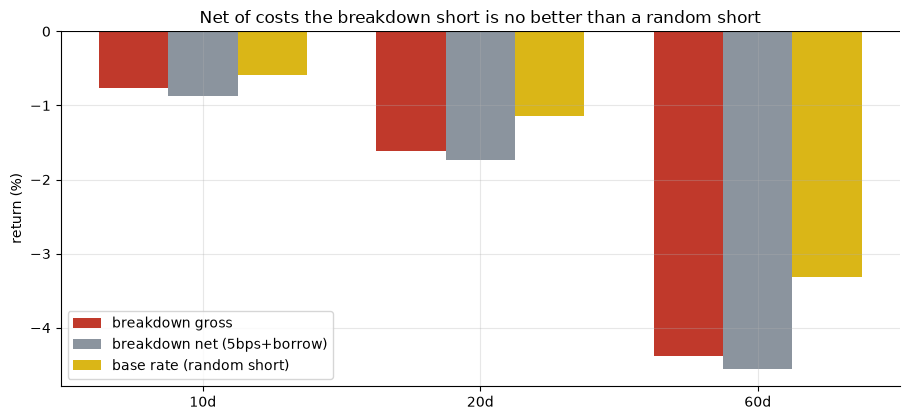

net: [-0.88, -1.74, -4.56]  base: [-0.59, -1.14, -3.32]


In [4]:
if HAVE_REAL:
    g, nv, bs = [], [], []
    for h in hs:
        r = st.run_experiment(PANEL, base_len=R['base_len'], horizon=h, cost_bps=5.0, borrow_bps=30.0, placebo=False)
        g.append(r['gross_mean']*100); nv.append(r['net_mean']*100); bs.append(r['base_mean']*100)
else:
    g=[R['h10'][2],R['h20'][2],R['h60'][2]]; nv=[R['h10'][3],R['h20'][3],R['h60'][3]]; bs=[R['h10'][4],R['h20'][4],R['h60'][4]]
x=np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2,4.3))
ax.bar(x-.25,g,.25,color=RED,label='breakdown gross')
ax.bar(x,nv,.25,color=GREY,label='breakdown net (5bps+borrow)')
ax.bar(x+.25,bs,.25,color=AMBER,label='base rate (random short)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('return (%)')
ax.set_title('Net of costs the breakdown short is no better than a random short'); ax.legend()
plt.tight_layout(); plt.show()
print('net:', [round(v,2) for v in nv], ' base:', [round(b,2) for b in bs])

> The honest bottom line: a rounding top is a **description of the past**, not a **prediction of the future**. By the time the breakdown confirms, the easy part — the roll-over from the peak — has already happened on the chart, and what's left is just the ordinary cost of betting against a market that goes up more often than it goes down.

## 7 · Going further 🚪

- **Subjectivity is the obvious escape hatch.** A believer can always say "that's not how *I'd* draw it." Fair — but a rule you can't write down is a rule you can't test or trade. Tighten or loosen the detector (we vary the window and fit threshold in the quants notebook) and the verdict doesn't budge.
- **Volume confirmation.** Classic lore adds *rising volume on the breakdown*. A natural next experiment: condition on a volume surge and re-test — does the base-rate gap open up?
- **The bullish mirror already tested.** [Study 416](../../416-rounding-bottom/) runs the exact same machinery on the saucer/rounding-bottom (long side) — same conclusion, opposite direction. Read them together for the full picture of this shape family.

*Think the dome beats a random short once you add volume? Show the breakdown's forward short return clearing the **base rate** at t ≥ 2, after borrow — then we'll talk.*